In [1]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import os

In [2]:
base_dir = os.getcwd()
german_dir = os.path.join(base_dir, 'Ex5', 'Data', 'german.data-numeric')

In [3]:
credit = np.genfromtxt(german_dir)
credit

array([[ 1.,  6.,  4., ...,  0.,  1.,  1.],
       [ 2., 48.,  2., ...,  0.,  1.,  2.],
       [ 4., 12.,  4., ...,  1.,  0.,  1.],
       ...,
       [ 4., 12.,  2., ...,  0.,  1.,  1.],
       [ 1., 45.,  2., ...,  0.,  1.,  2.],
       [ 2., 45.,  4., ...,  0.,  1.,  1.]], shape=(1000, 25))

In [4]:
X = credit[:,:-1]
y = credit[:,-1]
X.shape, y.shape

((1000, 24), (1000,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 24), (200, 24), (800,), (200,))

In [6]:
dt = DecisionTreeClassifier(random_state = 36)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(accuracy_score(y_test, y_pred_dt))
print(f1_score(y_test, y_pred_dt))
print(roc_auc_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))


0.635
0.7402135231316725
0.5637095804784229
[[104  37]
 [ 36  23]]


Ví dụ về roc auc, dưới sự thay đổi của ngưỡng ta được diagram
* roc là tên đường cong
* auc là diện tích phía dưới nếu diện tích càng lớn thì phân loại càng tốt
* TPR: tỉ lệ dương tính thật được tính dựa trên công thức tính recall: số lượng được dự đoán là dương tính trên tổng số lượng dương tính thật
* FPR: tỉ lệ dương tính giả: số lượng âm tính bị nhầm là dương tính trên tổng số âm tính, FP/FP+TN
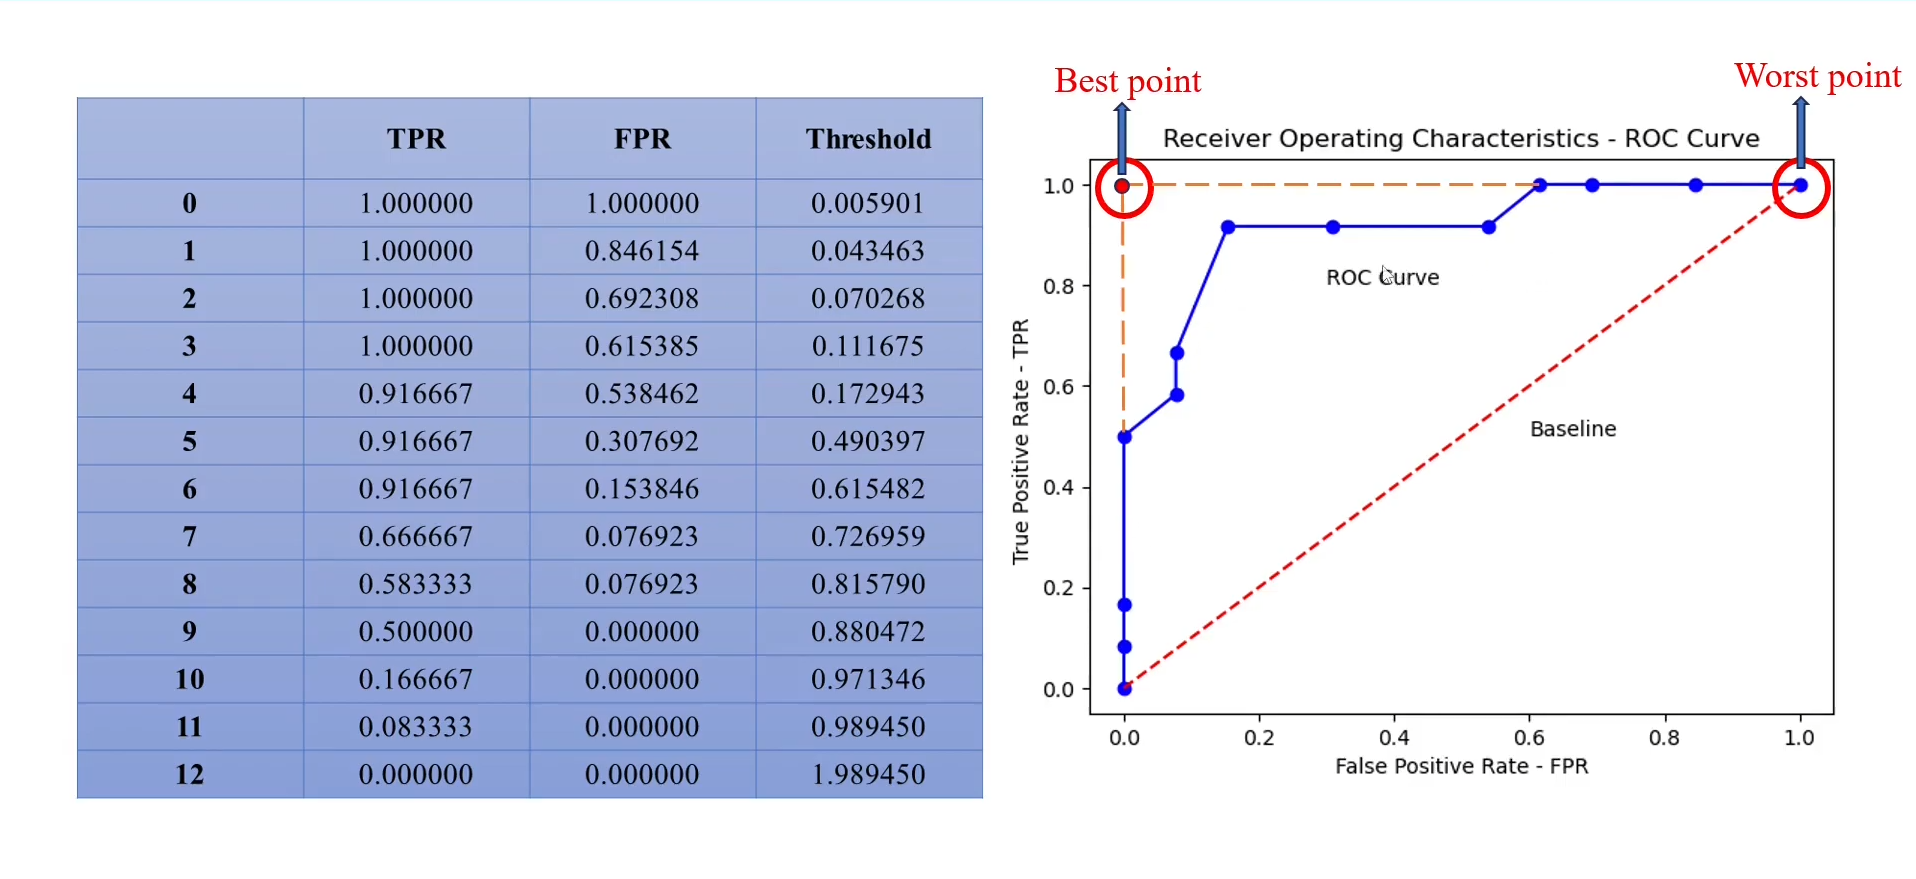

In [7]:
# RF baseline
rf = RandomForestClassifier(random_state = 36)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))
print(f1_score(y_test, y_pred_rf))
print(roc_auc_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

0.78
0.8562091503267973
0.6764034138718596
[[131  10]
 [ 34  25]]


base line rf tốt hơn decision tree

In [8]:
# dict_param là 1 dictionary có key là các tên của tham số của mô hình, value là các list mà các tham số có thể đạt được
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier(random_state = 36)
    if algorithm == 'random-forest':
        model = RandomForestClassifier(random_state = 36)
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                                                n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model ', end='')
    print(classifier.best_estimator_)
    return classifier.best_estimator_

# số lần train sẽ là số tổ hợp của tham số mô hình truyền vào trong grid * 
# số lần huấn luyện lấy từ cv(k fold)

In [9]:
def evaluate(model):
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

In [10]:
def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5),
                        new_plot=False, idx_color = 0):
    if new_plot == True:
        plt.figure(figsize = (16,9))
        plt.title(title)
        plt.xlabel("training examples")
        plt.ylabel("score")
        plt.grid()
    if ylim is not None:
        plt.ylim(ylim[0],ylim[1])
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring="f1")
    train_scores_mean = np.mean(train_scores, axis = 1)
    train_scores_std = np.std(train_scores, axis = 1)
    test_scores_mean = np.mean(test_scores, axis = 1)
    test_scores_std = np.std(test_scores, axis = 1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha = 0.2, color = 'g')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha = 0.2, color = 'r')
    plt.plot(train_sizes, test_scores_mean, marker = 'o', color = 'r', label = label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, marker = 'o', color = 'g', label = label_curve['train'])
    plt.legend(loc = 'best')
    return plt
    

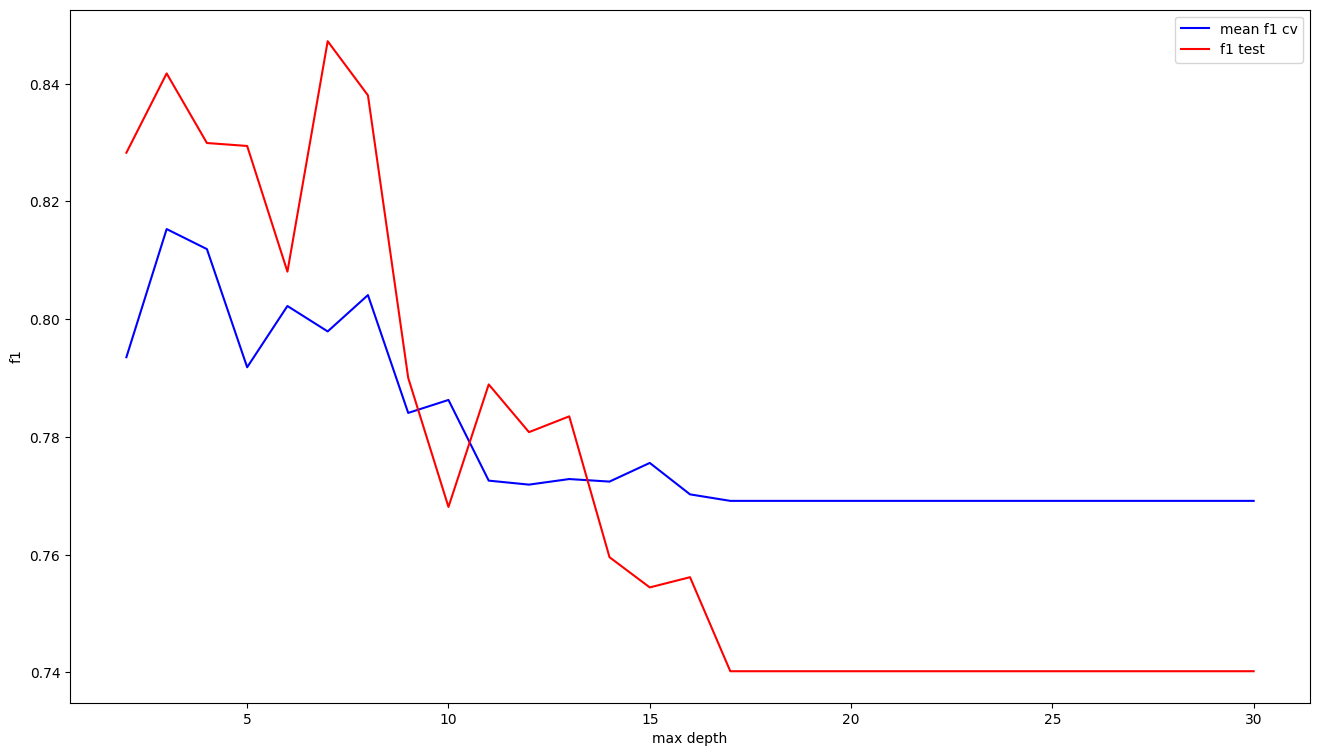

In [11]:
# Decision Tree
cv_accuracies_by_depth = [] # f1 score
test_accuracies_by_depth = []
max_depth_values = np.arange(2,31)

# tại mỗi max depth tính f1 score trung bình của các fold và f1 của test
for curr_max_depth in max_depth_values:
    tree = DecisionTreeClassifier(random_state = 36, max_depth = curr_max_depth)
    val_scores = cross_val_score(estimator = tree, X=X_train, y=y_train, cv=5, scoring = 'f1')
    cv_accuracies_by_depth.append(val_scores.mean())
    tree.fit(X_train, y_train)
    curr_pred = tree.predict(X_test)
    test_accuracies_by_depth.append(f1_score(y_test, curr_pred))

plt.figure(figsize = (16,9))
plt.plot(max_depth_values, cv_accuracies_by_depth, color = 'b', label = 'mean f1 cv')
plt.plot(max_depth_values, test_accuracies_by_depth, color = 'r', label = 'f1 test')
plt.xlabel('max depth')
plt.ylabel('f1')
plt.legend(loc = 'best')


Có thể thấy từ độ cao tối đa là 17 18 trở đi thì độ chính xác trên tập test và tập val không giảm đi nữa khả năng cao là overfit từ lúc độ cao tối đa là 17

cây quyết định với độ sâu tối đa 17 có overfit

In [12]:
cross_val_score(DecisionTreeClassifier(), X_train, y_train, cv=5, scoring = 'f1' )

array([0.7706422 , 0.75675676, 0.76785714, 0.79090909, 0.8       ])

In [13]:
# từ biểu đồ trên có thể chọn được ra các ứng viên max_depth sau
dict_param = {
    'max_depth' : [3,4,6,7,8,20],
    'min_samples_leaf' : [5,10,20,50,100],
    'criterion' : ['gini', 'entropy']
}
grid_search('decision-tree', n_jobs = -1, dict_param=dict_param)

Best model DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=36)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",36
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [14]:
# đánh giá the choosen tree
the_choosen_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20)
the_choosen_tree.fit(X_train, y_train)
evaluate(the_choosen_tree)
y_pred_choosen_tree = the_choosen_tree.predict(X_test)

Train Accuracy : 0.76125
Train f1 score : 0.8379983036471587
Train roc auc : 0.6804496767345364
Train Confusion Matrix:
[[494  65]
 [126 115]]
--------------------------------------------------
Test Accuracy : 0.765
Test f1 score : 0.8417508417508418
Test roc auc : 0.6805505469407381
Test Confusion Matrix:
[[125  16]
 [ 31  28]]


<module 'matplotlib.pyplot' from 'c:\\Weekly_Hw_GR1\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

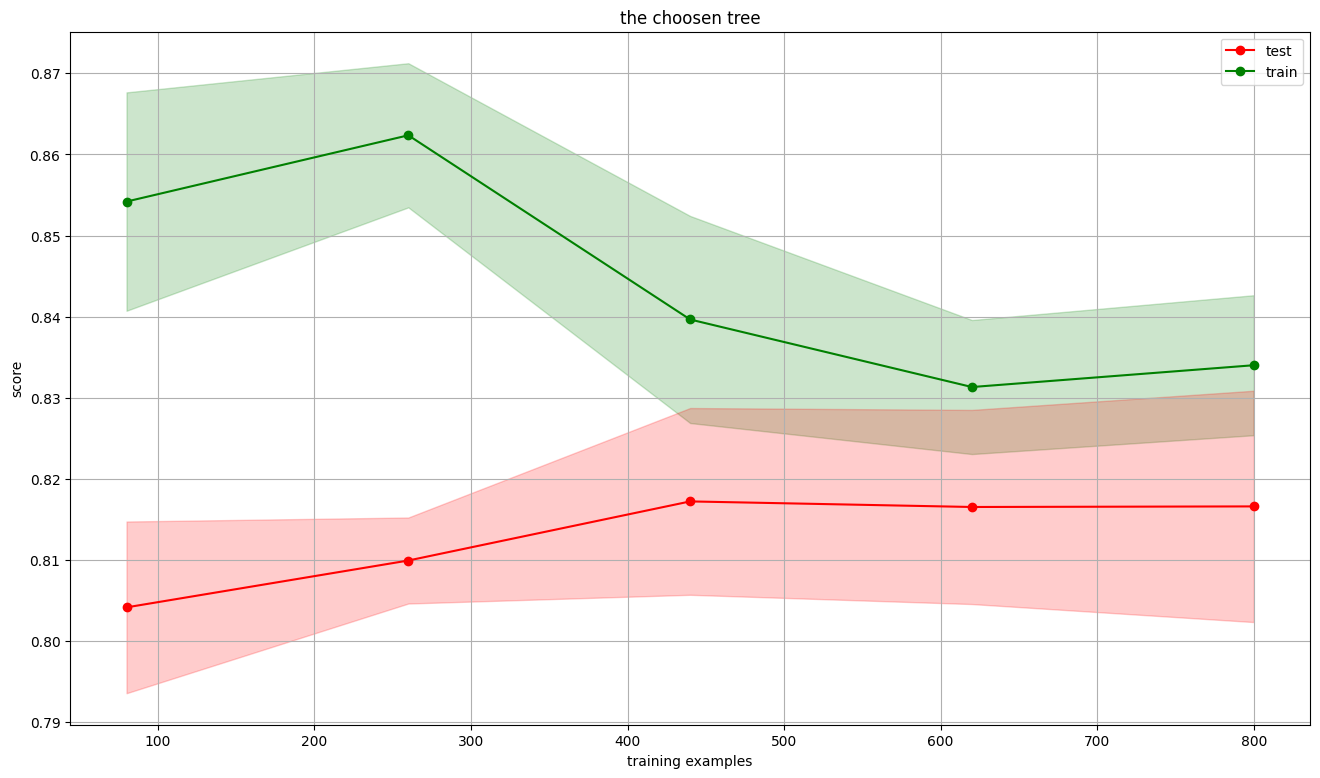

In [15]:
plot_learning_curve(the_choosen_tree, 'the choosen tree', {'test':'test', 'train':'train'}, X, y, n_jobs = -1, new_plot = True)

In [16]:
importances = the_choosen_tree.feature_importances_
importances

array([0.50739793, 0.1473292 , 0.12979184, 0.        , 0.09115425,
       0.        , 0.        , 0.01932028, 0.        , 0.03587269,
       0.06913381, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

top 10 features:
feature 0 - 0.5073979297726903
feature 1 - 0.14732919800019773
feature 2 - 0.12979184223119886
feature 4 - 0.09115424946084284
feature 10 - 0.06913380856263672
feature 9 - 0.03587269387979317
feature 7 - 0.019320278092640593
feature 23 - 0.0
feature 16 - 0.0
feature 17 - 0.0


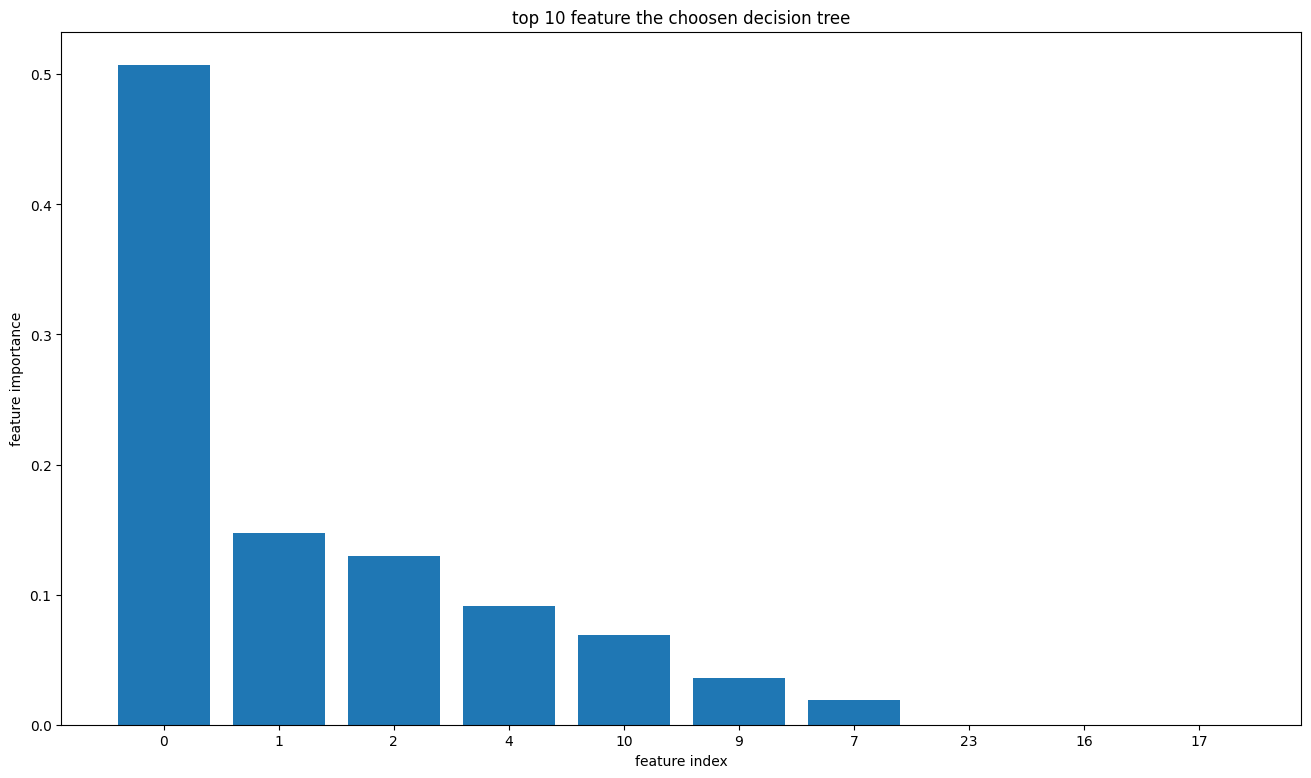

In [17]:
ind = np.argsort(importances)[::-1]
ind = ind[:10]
print('top 10 features:')
for i in ind:
    print(f"feature {i} - {importances[i]}")

plt.figure(figsize = (16,9))
plt.title('top 10 feature the choosen decision tree')
plt.xlabel('feature index')
plt.ylabel('feature importance')
plt.bar(range(10), importances[ind])
plt.xticks(range(10), ind)
plt.show()

Mức độ quan trọng của các feature trong decision tree được tính bằng độ giảm entropy hoặc gini tại các node có feature đó 

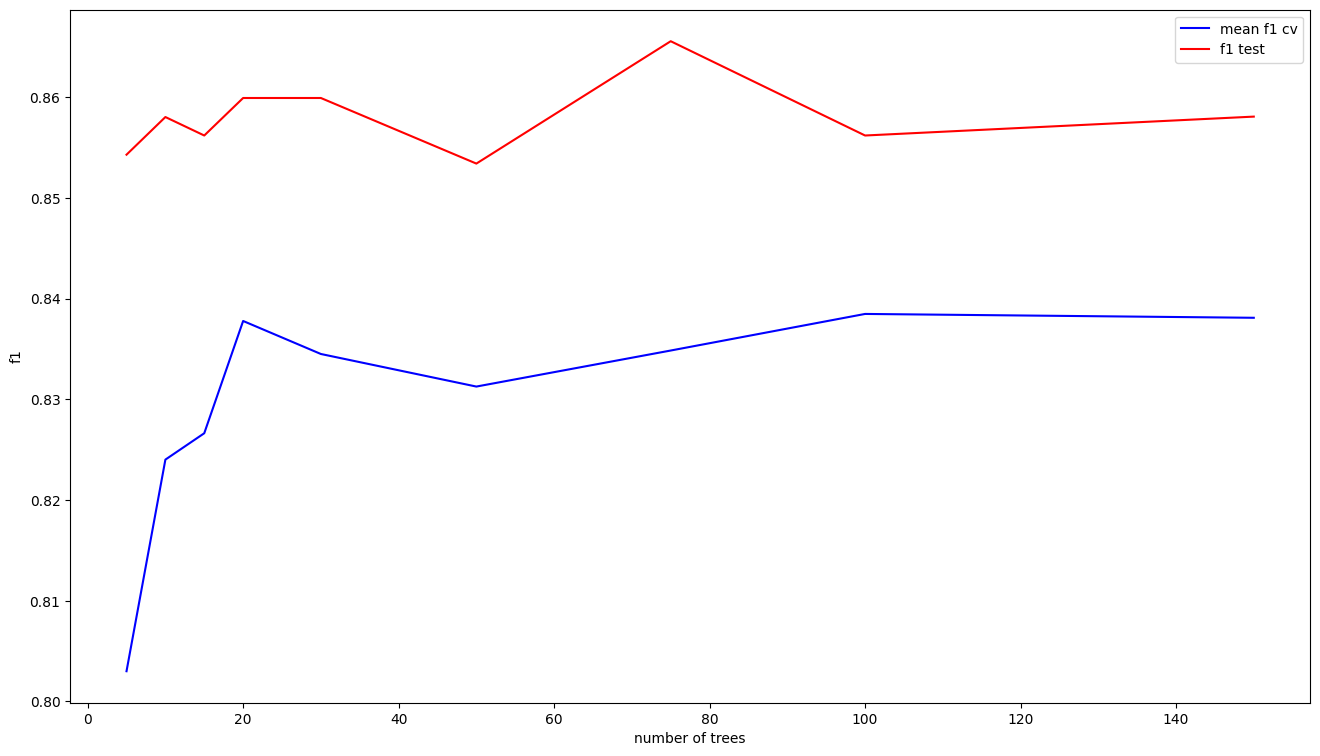

In [18]:
# Random Forest
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]
cv_f1_rf = []
test_f1_rf = [] 
for i in num_trees:
    rf = RandomForestClassifier(n_estimators = i, random_state = 36)
    val_scores = cross_val_score(estimator = rf, X = X_train, y = y_train, cv = 5, scoring = 'f1')
    cv_f1_rf.append(val_scores.mean())
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    test_f1_rf.append(f1_score(y_test, y_pred_rf))

plt.figure(figsize = (16,9))
plt.plot(num_trees, cv_f1_rf, color = 'b', label = 'mean f1 cv')
plt.plot(num_trees, test_f1_rf, color = 'r', label = 'f1 test')
plt.xlabel('number of trees')
plt.ylabel('f1')
plt.legend(loc = 'best')


In [19]:
dict_param = {
    'n_estimators' : range(50,201,10),
    'criterion': ['gini','entropy'],
    'max_features' : range(4,9),
    'min_samples_leaf' : [5,10,20,50,100],
}
x = grid_search('random-forest', n_jobs = -1, dict_param = dict_param)

Best model RandomForestClassifier(max_features=8, min_samples_leaf=5, n_estimators=120,
                       random_state=36)


In [20]:
the_choosen_rf = RandomForestClassifier(max_features=8, min_samples_leaf=5, n_estimators=120,
                       random_state=36)
the_choosen_rf.fit(X_train, y_train)
evaluate(the_choosen_rf)

Train Accuracy : 0.8775
Train f1 score : 0.9175084175084175
Train roc auc : 0.8132037797192675
Train Confusion Matrix:
[[545  14]
 [ 84 157]]
--------------------------------------------------
Test Accuracy : 0.785
Test f1 score : 0.8590163934426229
Test roc auc : 0.684877990143046
Test Confusion Matrix:
[[131  10]
 [ 33  26]]


<module 'matplotlib.pyplot' from 'c:\\Weekly_Hw_GR1\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

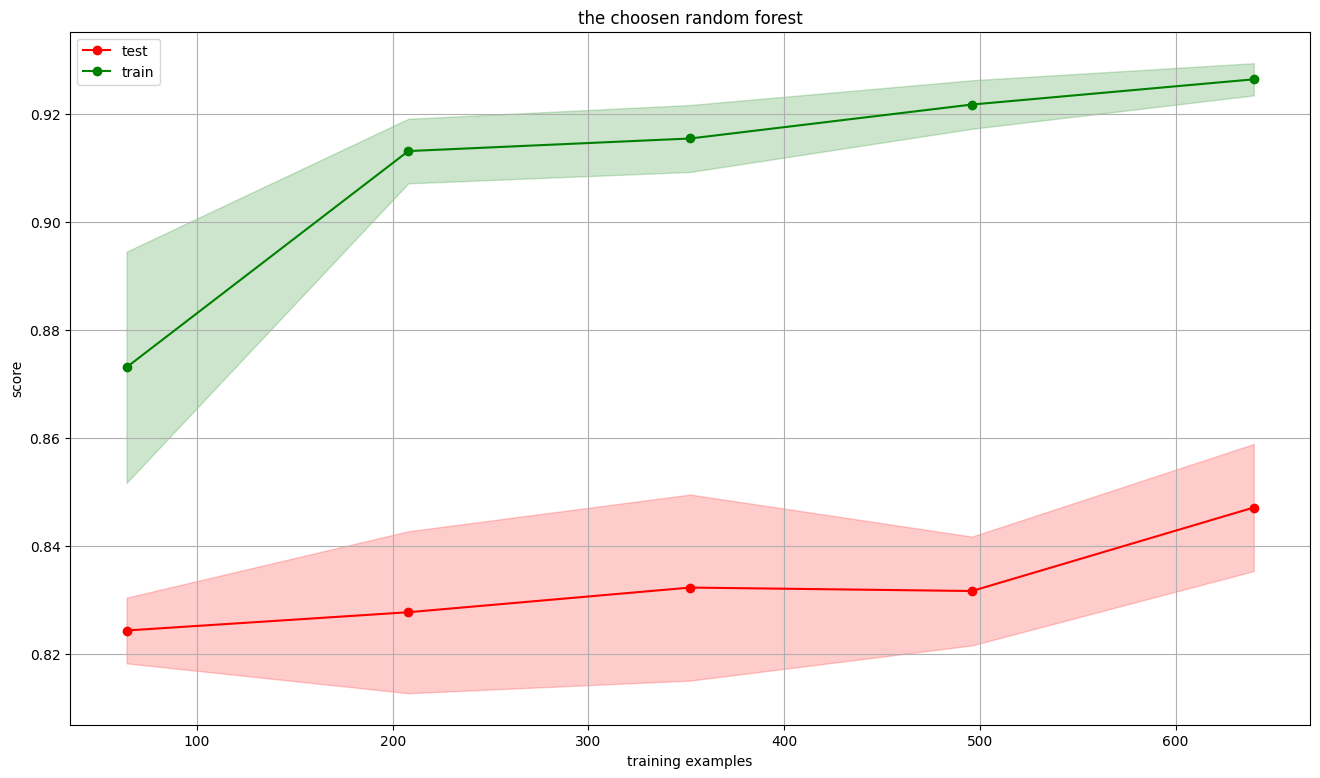

In [ ]:
plot_learning_curve(the_choosen_rf, 'the choosen random forest', {'test':'test', 'train':'train'}, X, y, n_jobs = -1, new_plot = True)

f1 score ổn định hơn so với model cây quyết định, mean thằng hàng hơn , độ lệch chuẩn bé hơn. Theo xu hướng thì nếu thêm data cho model thì score của test có thể tăng tiếp

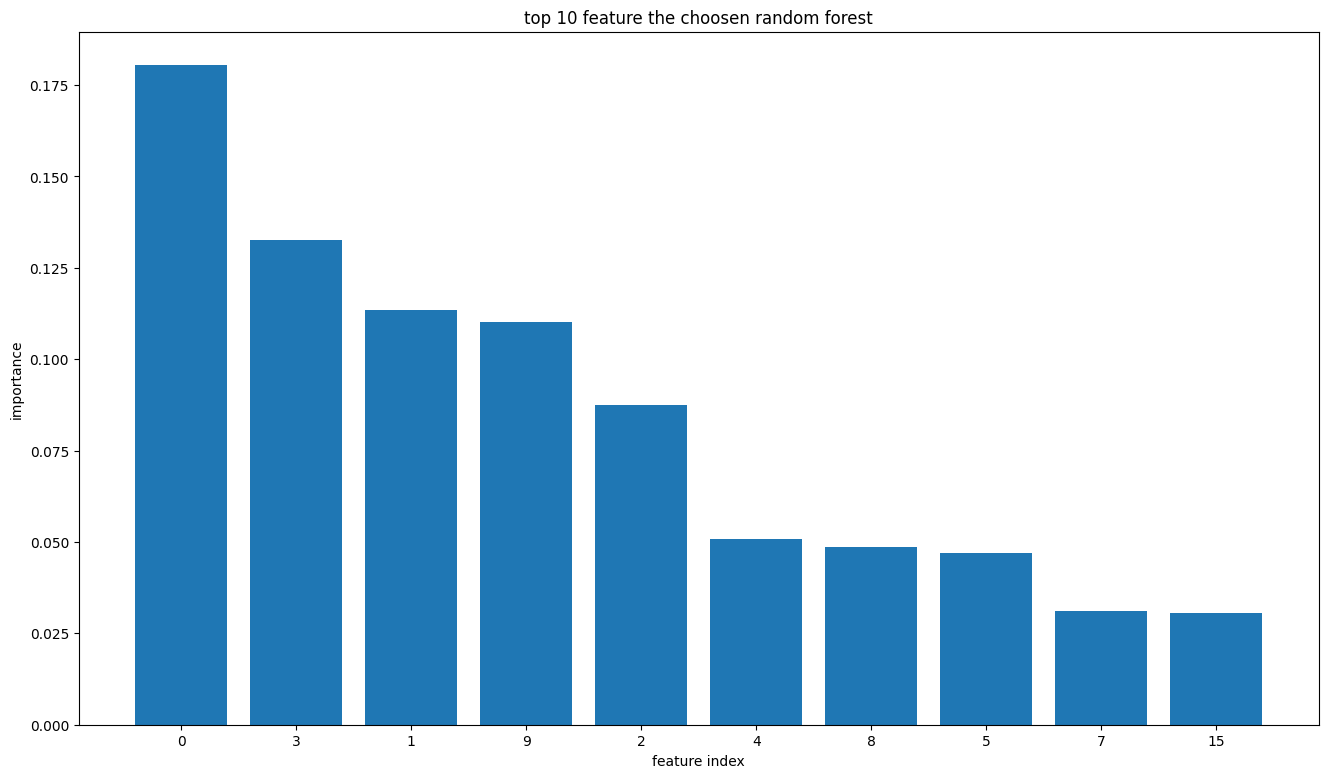

In [22]:
importance = the_choosen_rf.feature_importances_
ind = np.argsort(importance)[::-1]
ind = ind[:10]
loc = [i for i in range(len(ind))]
plt.figure(figsize = (16,9))
plt.title('top 10 feature the choosen random forest')
plt.xlabel('feature index')
plt.ylabel('importance')
plt.bar(loc, importance[ind])
plt.xticks(loc, ind)
plt.show()


In [23]:
# bỏ feature có độ quan trọng thấp
sfm = SelectFromModel(the_choosen_rf, threshold = 'mean')
sfm.fit(X_train, y_train)
X_train_dropped = sfm.transform(X_train)
X_test_dropped = sfm.transform(X_test)
the_choosen_rf_dropped = RandomForestClassifier(max_features=8, min_samples_leaf=5, n_estimators=120,
                       random_state=36)
the_choosen_rf_dropped.fit(X_train_dropped, y_train)
y_pred_rf_dropped = the_choosen_rf_dropped.predict(X_test_dropped)
print(f"accuracy: {accuracy_score(y_test, y_pred_rf_dropped)}")
print(f"f1 score: {f1_score(y_test, y_pred_rf_dropped)}")
print(f"roc auc score: {roc_auc_score(y_test, y_pred_rf_dropped)}")


accuracy: 0.815
f1 score: 0.8778877887788779
roc auc score: 0.725868493809352


<module 'matplotlib.pyplot' from 'c:\\Weekly_Hw_GR1\\venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

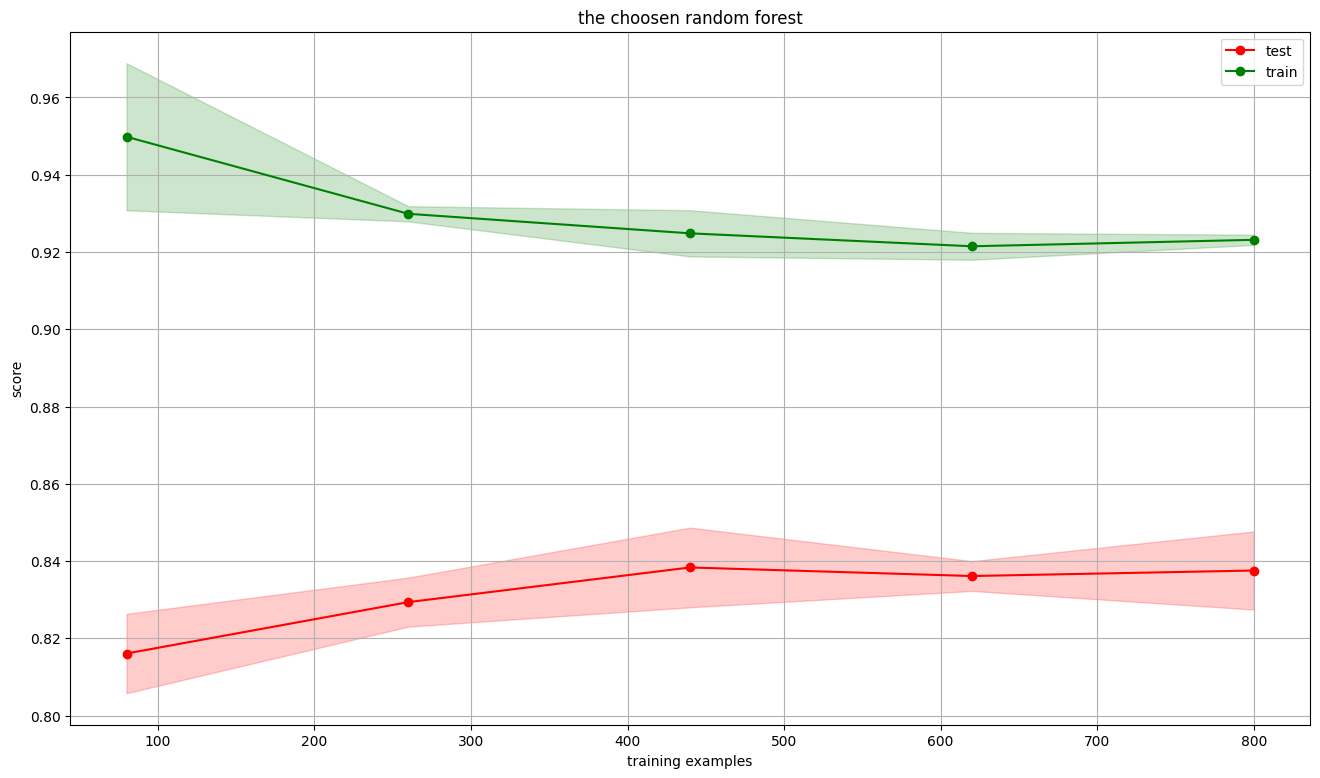

In [26]:
plot_learning_curve(the_choosen_rf_dropped, 'the choosen random forest', {'test':'test', 'train':'train'}, sfm.transform(X), y, n_jobs = -1, new_plot = True)

In [34]:
# xem thử phân bố của các class
import pandas as pd
df = pd.Series(y)

In [35]:
df.value_counts()

1.0    700
2.0    300
Name: count, dtype: int64

Số lượng nhãn 1 chiếm hơn 2/3 tổng số lượng sample

In [ ]:
# class weight là mức độ ưu tiên của các nhãn
# nếu để là balanced thì lớp nào ít mẫu trọng số càng cao 
rf1 = RandomForestClassifier(max_features=8, min_samples_leaf=5, n_estimators=120,
                        class_weight='balanced', random_state=36)
rf1.fit(X_train, y_train)
evaluate(rf1)

Train Accuracy : 0.89875
Train f1 score : 0.925756186984418
Train roc auc : 0.8956828658169969
Train Confusion Matrix:
[[505  54]
 [ 27 214]]
--------------------------------------------------
Test Accuracy : 0.795
Test f1 score : 0.8540925266903915
Test roc auc : 0.7560403894698882
Test Confusion Matrix:
[[120  21]
 [ 20  39]]


In [43]:
# nếu để class weight là balanced_subsample thì nó tính toán linh hoạt theo
# các cây trong rừng dựa trên bootstrap
rf2 = RandomForestClassifier(max_features=8, min_samples_leaf=5, n_estimators=120,
                        class_weight='balanced_subsample', random_state=36)
rf2.fit(X_train, y_train)
evaluate(rf2)

Train Accuracy : 0.89375
Train f1 score : 0.9222323879231473
Train roc auc : 0.888564345044129
Train Confusion Matrix:
[[504  55]
 [ 30 211]]
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.8428571428571429
Test roc auc : 0.7404736146171415
Test Confusion Matrix:
[[118  23]
 [ 21  38]]


In [44]:
from imblearn.ensemble import BalancedRandomForestClassifier
rf3 = BalancedRandomForestClassifier(max_features=8, min_samples_leaf=5, n_estimators=120,
                                    random_state=36)
rf3.fit(X_train, y_train)
evaluate(rf3)

Train Accuracy : 0.85
Train f1 score : 0.8850574712643678
Train roc auc : 0.8655200825421804
Train Confusion Matrix:
[[462  97]
 [ 23 218]]
--------------------------------------------------
Test Accuracy : 0.75
Test f1 score : 0.8091603053435115
Test roc auc : 0.7487678807548984
Test Confusion Matrix:
[[106  35]
 [ 15  44]]


BalancedRandomForestClassifier thực hiện balance bootstraping, trong lúc bootstrap nó sẽ lấy lặp lại m mẫu minor trong tất cả m mẫu minor gốc và m mẫu major (ko lặp lại).

In [57]:
rf3.get_params()
# 'sampling_strategy': 'all' lấy bootstrap sao cho phân phối của các nhãn là giống nhau trong 1 cây

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 8,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 120,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 36,
 'replacement': True,
 'sampling_strategy': 'all',
 'verbose': 0,
 'warm_start': False}